# Классификация IC50 > median

Задача бинарная и почти идеально сбалансированная, поэтому удобно сравнивать модели по `ROC-AUC`, `F1` и `Balanced Accuracy`.

Порог взят фиксированный: `46.585183`, это медиана по датасету.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Рабочая директория: /Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry


In [2]:
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from src.common.config import RESULTS_DIR, TASKS
from src.common.data import find_dataset_path, load_dataset
from src.common.preprocessing import prepare_task_data
from src.common.training import run_regression_si_task, run_supervised_task

## Настройки запуска

По умолчанию стоит полный режим `nested`. Если нужен быстрый прогон для проверки,
достаточно переключить `EVALUATION_STRATEGY` на `"holdout"`.

In [3]:
TASK_NAME = 'classification_ic50_gt_median'
EVALUATION_STRATEGY = 'nested'
MODELS = None
SKIP_CATBOOST = False
OUTER_FOLDS = 5
INNER_FOLDS = 3
TEST_SIZE = 0.2
RANDOM_SEED = 42
TOP_K_IMPORTANCE = 20

task = TASKS[TASK_NAME]
dataframe = load_dataset(find_dataset_path())
prepared = prepare_task_data(dataframe, task)

print(f'Задача: {task.title}')
print(f'Матрица признаков: {prepared["X"].shape}')
print(f'Число признаков после фильтрации: {len(prepared["feature_columns"])}')
print(f'Статус проверки на утечку: {prepared["leakage_report"]["status"]}')

Задача: Классификация: IC50 > 46.585183
Матрица признаков: (1001, 210)
Число признаков после фильтрации: 210
Статус проверки на утечку: passed


## Быстрый срез по таргету

Перед обучением полезно один раз посмотреть, что именно мы подаём в модель.

In [12]:
target_frame = (
    prepared['y']
    .value_counts()
    .sort_index()
    .rename_axis('label')
    .reset_index(name='count')
)
target_frame['share'] = target_frame['count'] / target_frame['count'].sum()
display(target_frame)

,label,count,share
0,0,500,0.4995
1,1,501,0.5005


## Запуск эксперимента

Эта ячейка пересчитывает результаты, пишет артефакты в `results/` и обновляет текстовый отчёт в `reports/`.

In [5]:
args = SimpleNamespace(
    evaluation_strategy=EVALUATION_STRATEGY,
    models=MODELS,
    skip_catboost=SKIP_CATBOOST,
    outer_folds=OUTER_FOLDS,
    inner_folds=INNER_FOLDS,
    test_size=TEST_SIZE,
    random_seed=RANDOM_SEED,
    top_k_importance=TOP_K_IMPORTANCE,
)

summary = run_supervised_task(task, args)
summary

2026-04-20 17:52:58,238 | INFO | Running classification_ic50_gt_median with models: ['dummy', 'logistic_regression', 'knn', 'svc', 'random_forest', 'extra_trees', 'gradient_boosting', 'catboost']
2026-04-20 17:52:58,238 | INFO | Evaluating model dummy
2026-04-20 17:52:58,741 | INFO | Evaluating model logistic_regression
2026-04-20 17:53:04,249 | INFO | Evaluating model knn
2026-04-20 17:53:16,053 | INFO | Evaluating model svc
2026-04-20 17:53:47,572 | INFO | Evaluating model random_forest
2026-04-20 18:01:21,812 | INFO | Evaluating model extra_trees
2026-04-20 18:04:36,168 | INFO | Evaluating model gradient_boosting
2026-04-20 18:08:42,294 | INFO | Evaluating model catboost
2026-04-20 18:23:32,823 | INFO | Finished classification_ic50_gt_median. Winner: extra_trees


{'task_name': 'classification_ic50_gt_median',
 'title': 'Классификация: IC50 > 46.585183',
 'problem_type': 'classification',
 'target_column': 'IC50, mM',
 'threshold': 46.585183,
 'primary_metric': 'roc_auc',
 'evaluation_strategy': 'nested',
 'random_seed': 42,
 'data_contract_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/data_contract.json',
 'leaderboard_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/classification_ic50_gt_median/leaderboard.csv',
 'winner': {'task_name': 'classification_ic50_gt_median',
  'problem_type': 'classification',
  'target_column': 'IC50, mM',
  'primary_metric': 'roc_auc',
  'evaluation_strategy': 'nested',
  'model_name': 'extra_trees',
  'mode': 'direct',
  'fit_seconds': 194.3531460420345,
  'best_params_json': '{"class_weight": "balanced", "max_depth": 16, "max_features": "sqrt", "min_samples_leaf": 5}',
  'roc_auc': 0.7908031683168317,
  'roc_auc_std

## Лидерборд

Сравнение разных моделей.

In [6]:
leaderboard = pd.read_csv(RESULTS_DIR / 'classification_ic50_gt_median' / 'leaderboard.csv')
display(leaderboard)

,task_name,problem_type,target_column,primary_metric,evaluation_strategy,model_name,mode,fit_seconds,best_params_json,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std
0,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,extra_trees,direct,194.353146,"{""class_weight"": ""balanced"", ""max_depth"": 16, ...",0.790803,0.027059,0.707717,0.022109,0.711356,0.023548
1,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,catboost,direct,890.459278,"{""depth"": 6, ""iterations"": 200, ""l2_leaf_reg"":...",0.789342,0.036327,0.704772,0.039679,0.708366,0.038704
2,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,random_forest,direct,454.302483,"{""class_weight"": null, ""max_depth"": 8, ""max_fe...",0.783358,0.028594,0.691054,0.032425,0.696406,0.026788
3,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,svc,direct,31.516118,"{""C"": 1.0, ""class_weight"": null, ""gamma"": ""sca...",0.775115,0.031048,0.708636,0.035175,0.702376,0.031386
4,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,gradient_boosting,direct,246.121017,"{""learning_rate"": 0.03, ""max_depth"": 3, ""n_est...",0.773362,0.028310,0.701994,0.029333,0.704327,0.027416
5,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,knn,direct,11.802301,"{""n_neighbors"": 11, ""p"": 1, ""weights"": ""uniform""}",0.762144,0.042668,0.692070,0.043643,0.697426,0.033819
6,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,logistic_regression,direct,5.504975,"{""C"": 0.1, ""class_weight"": null}",0.754866,0.046571,0.683395,0.044084,0.684396,0.037115
7,classification_ic50_gt_median,classification,"IC50, mM",roc_auc,nested,dummy,direct,0.500485,"{""strategy"": ""prior""}",0.501000,0.002000,0.510553,0.259060,0.511000,0.022000


## Короткий разбор результата

In [7]:
winner = leaderboard.iloc[0]
baseline_rows = leaderboard[leaderboard['model_name'] == 'dummy']
baseline = baseline_rows.iloc[0] if not baseline_rows.empty else None

print(
    f"Победитель: {winner['model_name']} "
    f"({winner['mode']}), "
    f"основная метрика {winner['primary_metric']} = {winner[winner['primary_metric']]:.6f}."
)
if baseline is not None:
    print(
        f"Для сравнения dummy даёт {baseline[baseline['primary_metric']]:.6f} по той же метрике."
    )
print(f"Лучшие параметры: {winner['best_params_json']}")

Победитель: extra_trees (direct), основная метрика roc_auc = 0.790803.
Для сравнения dummy даёт 0.501000 по той же метрике.
Лучшие параметры: {"class_weight": "balanced", "max_depth": 16, "max_features": "sqrt", "min_samples_leaf": 5}


## Что видно по важности признаков

In [11]:
importance_path = RESULTS_DIR / 'classification_ic50_gt_median' / 'winner_feature_importance.csv'
if importance_path.exists():
    display(pd.read_csv(importance_path).head(15))

,feature,importance,abs_importance
0,NumSaturatedHeterocycles,0.024975,0.024975
1,NHOHCount,0.015829,0.015829
2,NumAliphaticHeterocycles,0.015539,0.015539
3,EState_VSA8,0.013414,0.013414
4,NumAliphaticCarbocycles,0.012897,0.012897
5,NumSaturatedCarbocycles,0.012502,0.012502
6,EState_VSA2,0.012297,0.012297
7,NumHDonors,0.012178,0.012178
8,VSA_EState4,0.011806,0.011806
9,fr_NH2,0.011720,0.011720


## Матрица ошибок

Для бинарных задач полезно смотреть не только на метрики, но и на тип ошибок.

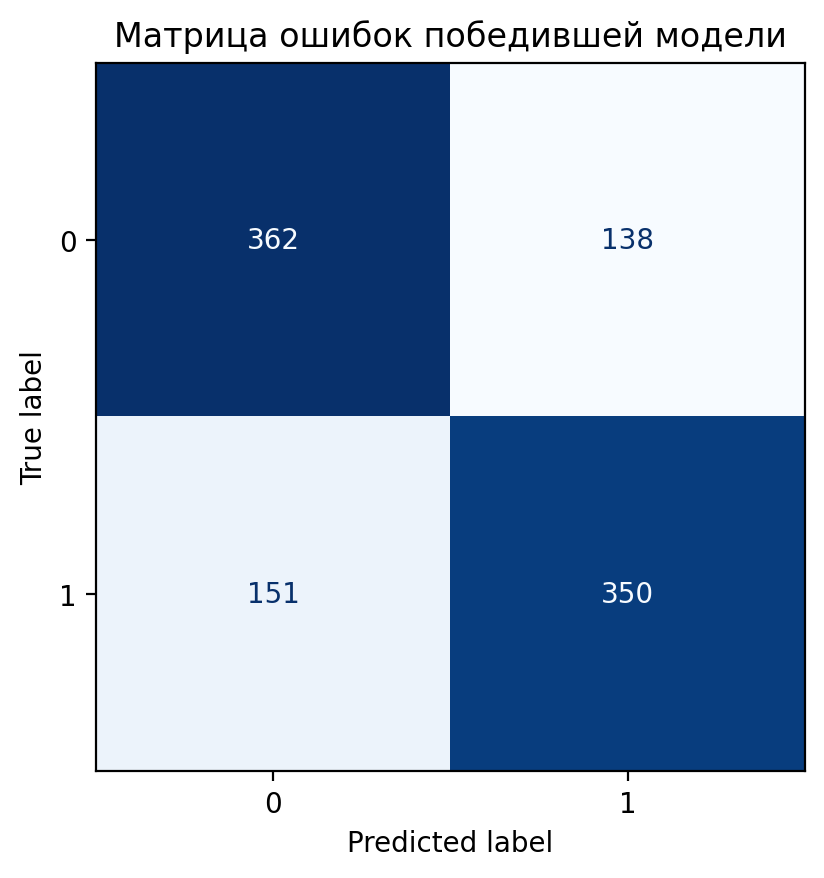

In [10]:
confusion_path = RESULTS_DIR / 'classification_ic50_gt_median' / 'winner_confusion_matrix.png'
if confusion_path.exists():
    display(Image(filename=str(confusion_path)))

## Итог
TODO: написать почему именно эта модель победила и порассуждать почему в этой задаче именно она показывает хороший результат